# From lens samples to modified gravity (and cosmological constraints): a coarse grained approach

**Goal**: to obtain constraints on the so-called γPPN or slip parameter from a set of strong lensing systems using information from the Einstein radius (θ_E), lens and source redshifts and lens stellar velocity dispersion σ. A similar approach to the one employed in this tutorial can be used to set constraints on the cosmological parameters and other applications.  


**Description**: The key is to combine information from lensing (θ_E) and the lens dynamics (through σ), with additional priors and information from the light distribution. This tutorial uses the custom built rings2cosmo code, which implements the modeling of Schwab et al. (2010) for the aperture- and seeing-weighted velocity dispersion of a power-law mass profile for the lens. Starting from a lens catalogue, a Gaussian likelihood and Gaussian priors we sample the full posterior with the affine-invariant ensemble sampler emcee. Along the way we cover the practical side of Bayesian inference (initialising walkers, burn-in, checking chain convergence with trace plots and autocorrelation times, reading corner plots, and testing the fit against the data) and we evaluate the modelling choices before we assume a final result.

---

**How this notebook is organised**

1. The physics in one equation
2. The `rings2cosmo` module
3. Loading a lens sample (your own CSV, or a mock sample so everything runs out of the box)
4. Best-fit parameters by optimisation
5. Sampling the posterior with `emcee`
6. Diagnosing the chains
7. Results: corner plot, credible intervals, and a check against the data
8. Einstein Radius Conventions & Multi-Group Analysis
9. Varying $\gamma$ Parameterization
10. Model Comparison using the Bayesian Information Criterion (BIC)

**Requirements:** `numpy`, `scipy`, `pandas`, `matplotlib`, `astropy`, `emcee`, `corner`
(`pip install emcee corner astropy`).

## 1. The physics in one equation

To see how we can test General Relativity, we must look at how light and mass couple. In modified gravity or parameterized post-Newtonian (PPN) formalisms, we introduce two Newtonian potentials: $\Phi$ (the temporal potential, which governs the dynamics of slow-moving particles like stars) and $\Psi$ (the spatial potential, which describes spatial curvature).

Light deflection is sensitive to the sum of these potentials, $\Phi + \Psi$. The Einstein deflection angle $\theta_E$ is given by integrating this sum along the line of sight $\lambda$:

\begin{equation}
    \theta_E = \frac{D_{LS}}{D_S}\hat{\vec{\alpha}}(R_E) = \frac{D_{LS}}{D_S}\frac{1}{c^2}\int^{\lambda_A}_{\lambda_B}\vec{\nabla}_\perp \left(\Phi(R_E)+\Psi(R_E)\right) d\lambda,
\end{equation}

where $R_E = D_L\theta_E$ is the physical Einstein radius. Introducing the PPN slip parameter $\gamma \equiv \Psi / \Phi$ (where GR predicts $\gamma = 1$), the lensing relation simplifies to:

\begin{equation}
    \theta_E = \frac{D_{LS}}{D_S}\frac{2GM_E}{R_E}\frac{(1+\gamma)}{c^2}.
\end{equation}

Conversely, stellar dynamics are governed only by the temporal potential $\Phi$. By solving the spherical Jeans equation under a given stellar orbital anisotropy $f(r)$, the radial velocity dispersion $\sigma_r$ relates directly to the gradient of the Newtonian potential $d\Phi/dr$:

\begin{equation}
    \nu(r)\sigma_r^2 = \frac{1}{f(r)}\int_r^{\infty} f(r')\nu(r')\frac{d\Phi(r')}{dr'}\, dr'.
\end{equation}

### Why can we measure $\gamma$ here?
By comparing the mass inferred from **gravitational lensing** (which measures $\Phi + \Psi \propto 1+\gamma$) with the mass inferred from **stellar dynamics** (which measures $\Phi$ alone), we break the degeneracy between the galaxy profile and the underlying theory of gravity, allowing us to set a direct constraint on the slip parameter $\gamma$.

Integrating these equations for a power-law mass profile ($\rho \propto r^{-\alpha}$), a stellar tracer profile ($\nu \propto r^{-\delta}$), and a constant orbital anisotropy ($\beta = 1 - \sigma_\theta^2/\sigma_r^2$), Schwab et al. (2010, eq. 23) derive the aperture- and seeing-weighted line-of-sight velocity dispersion:

$$
\sigma_*^2 = \left[\frac{2}{1+\gamma}\right]\frac{c^2}{4}\,\frac{D_S}{D_{LS}}\,\theta_E\;
\frac{2}{\sqrt{\pi}}\,\frac{\left(2\tilde\sigma_{\rm atm}^2/\theta_E^2\right)^{1-\alpha/2}}{\xi-2\beta}
\left[\frac{\lambda(\xi)-\beta\,\lambda(\xi+2)}{\lambda(\alpha)\,\lambda(\delta)}\right]
\frac{\Gamma\!\left(\frac{3-\xi}{2}\right)}{\Gamma\!\left(\frac{3-\delta}{2}\right)},
$$

with $\xi = \alpha + \delta - 2$, $\lambda(x) = \Gamma\!\left(\frac{x-1}{2}\right)/\Gamma\!\left(\frac{x}{2}\right)$, and $\tilde\sigma_{\rm atm}$ representing the combined effect of atmospheric seeing $\sigma_{atm}$ and spectroscopic aperture radius $\theta_{\rm ap}$.

### Physical Degeneracy
Note that the physical parameters $\alpha$ (mass profile slope), $\beta$ (stellar orbital anisotropy), $\delta$ (stellar density slope), and $\gamma$ (gravity slip) are partly degenerate. For example, if the mass density profile is steeper (higher $\alpha$), it places more mass near the center, which increases the predicted velocity dispersion. We can compensate for this change (producing the same observed dispersion) by adjusting the orbital anisotropy $\beta$ or the gravity slip parameter $\gamma$. This physical covariance is why robust independent priors on galaxy parameters are vital for obtaining clean constraints on gravity.

## 2. The `rings2cosmo` module

We will use the external `rings2cosmo` library to perform our lens analysis. The module contains optimized physics, likelihood estimation, optimization routines, and MCMC sampling procedures. In the following sections, we will walk through how these parameters are structured and evaluated.

### 2a. The velocity-dispersion model

`ratio_gamma` is the $\lambda(x)$ function above, and `vel` evaluates eq. 23. Note that `vel` returns
$\sqrt{|\sigma_*^2|}$ in km/s.

* **Numerical safeguards**: The absolute value inside the square root keeps the code from crashing when an unphysical parameter combination (such as extreme values of $\beta$ or $\alpha$) makes the predicted $\sigma_*^2$ negative.
* **Bayesian boundary handling**: Although the math uses an absolute value to prevent complex values, the sampler restricts these unphysical regions because the prior settings or the log-likelihood function assign negative or $-\infty$ log-probability to coordinates that violate stability bounds, stopping the MCMC chain from spending time there.

### 2b. Likelihood, prior and posterior

* **Likelihood.** Each lens contributes a Gaussian term comparing the measured and model dispersions:
  $\ln\mathcal{L} = -\tfrac12\sum_i\left[(\sigma_i-\sigma_{\rm model,i})^2/\Delta\sigma_i^2 + \ln(2\pi\Delta\sigma_i^2)\right]$.
* **Prior.** Gaussian on α, β, δ, and a hard box at ±5 prior widths outside which the probability is
  zero. This hard box may need to be widened if you find your walkers are not exploring the parameter space, shrinking might help if the walkers are not converging. γ has **no** prior term, so it is effectively flat and unbounded; it is constrained by the data alone.
* **Posterior.** `log_probability` = log-prior + log-likelihood. Returning `-np.inf` tells `emcee` to
  reject a proposed step outright, and skipping the likelihood there saves time.

### 2c. Optimisation and sampling

* `minimization_loglikelihood` finds the **maximum-likelihood** point (no priors).
* `minimization_logprobability` finds the **maximum a posteriori** (MAP) point (with priors).
  Both minimise the *negative* of the function with `scipy.optimize.minimize`, starting from the prior
  means plus a tiny random jitter.
* `logprobability_sampling` runs `emcee`. It starts every walker in a small ball (width $10^{-3}$)
  around the maximum-likelihood point, runs `n_burn` burn-in steps, throws them away with
  `sampler.reset()`, then runs `n_steps` production steps from where the burn-in ended.

In [5]:
with open('rings2cosmo.py', 'r', encoding='latin-1') as f:
    content = f.read()

# Standardize any legacy non-UTF-8 characters
with open('rings2cosmo.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("rings2cosmo.py has been successfully re-encoded to UTF-8!")

rings2cosmo.py has been successfully re-encoded to UTF-8!


In [7]:
%pip install emcee corner astropy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import sys
import rings2cosmo  # Uncomment this once rings2cosmo.py line 355 has been fixed

print("emcee version:", emcee.__version__)
print("python version:", sys.version)

emcee version: 3.1.6
python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 3. Loading a lens sample

`rings2cosmo` expects seven arrays, one entry per lens:

| argument | meaning | units |
|---|---|---|
| `z_S`, `z_L` | source and lens redshifts | — |
| `velDisp`, `velDispErr` | measured velocity dispersion and its 1σ error | km/s |
| `theta_E` | Einstein radius | **radians** |
| `seeing_atm` | atmospheric seeing | **radians** |
| `theta_ap` | spectroscopic aperture radius | **radians** |

Catalogues usually give angles in arcseconds, so convert them.

Set `DATA_PATH` to your catalogue and edit `COLUMNS` so each key points to the matching column name in your file.

### Column Descriptions in `05_Combined_Data.csv`:
* **`JNAME` / `Original_ID`**: Unique names identifying each lens system.
* **`z_L`**: Lens redshift.
* **`z_S`**: Source redshift.
* **`velDisp` / `velDispErr`**: Spectroscopic central stellar velocity dispersion and its error.
* **`velDisp0` / `velDisp0Err`**: Aperture-corrected stellar velocity dispersion and its corresponding error.
* **`theta_E`**: Einstein radius in arcseconds.
* **`theta_ap`**: Spectroscopic fiber aperture radius in arcseconds.
* **`Seeing`**: Atmospheric seeing FWHM in arcseconds.
* **`theta_E_rad` / `theta_ap_rad` / `Seeing_rad`**: Equivalent values converted directly to radians for computational compatibility with the physics equations.
* **`Survey`**: Origin survey name (e.g., SLACS, BELLS, LSD).
* **`axis_ratio`**: Projected minor-to-major axis ratio ($q = b/a$) of the lens galaxy.
* **`theta_E_convention`**: Label indicating the specific Einstein radius convention used in the source paper.

In [9]:
from pathlib import Path
import numpy as np

DATA_PATH = Path("05_Combined_Data.csv")      # <- your lens catalogue

# Map the names rings2cosmo uses (keys) to the column names in YOUR file (values).
COLUMNS = {
    "z_L":        "z_L",
    "z_S":        "z_S",
    "velDisp":    "velDisp0",
    "velDispErr": "velDisp0Err",
    "theta_E":    "theta_E_rad",    # arcsec in the file
    "theta_ap":   "theta_ap_rad",   # arcsec in the file
    "seeing_atm": "Seeing_rad",     # arcsec in the file
}


TRUE_PARAMS = dict(alpha=2.0, beta=0.18, delta=2.4, gamma=1.0)   # used only for the mock


def load_catalogue(path, columns):
    df = pd.read_csv(path)
    print(df.columns)
    data = {key: df[col].to_numpy(dtype=float) for key, col in columns.items()}
    return df, data



df, data = load_catalogue(DATA_PATH, COLUMNS)
print(f"Loaded {len(df)} lenses from {DATA_PATH}")


df.head()

Index(['JNAME', 'Original_ID', 'z_L', 'z_S', 'velDisp', 'velDispErr',
       'velDisp0', 'velDisp0Err', 'theta_E', 'theta_ap', 'theta_Eff', 'Seeing',
       'theta_E_rad', 'theta_ap_rad', 'theta_Eff_rad', 'Seeing_rad',
       'Reference', 'in_cao_2015', 'in_cao_2017', 'in_chen_2019',
       'in_liu_2022', 'in_lastberu_cosmo_ground', 'Survey', 'GROUND_SPACE',
       'axis_ratio', 'axis_ratio_err', 'theta_E_convention'],
      dtype='object')
Loaded 206 lenses from 05_Combined_Data.csv


,JNAME,Original_ID,z_L,z_S,velDisp,velDispErr,velDisp0,velDisp0Err,theta_E,theta_ap,...,in_cao_2015,in_cao_2017,in_chen_2019,in_liu_2022,in_lastberu_cosmo_ground,Survey,GROUND_SPACE,axis_ratio,axis_ratio_err,theta_E_convention
0,J015107.4+004909.0,SDSSJ0151+0049,0.517,1.364,219.0,39.0,235.391707,43.350262,0.68,1.0,...,True,True,True,True,False,BELLS,SPACE,0.752,0.0,Intermediate
1,J074724.1+505537.5,SDSSJ0747+5055,0.438,0.898,328.0,60.0,341.406413,63.655064,0.75,1.0,...,True,False,True,True,False,BELLS,SPACE,0.641,0.0,Intermediate
2,J074734.8+444859.3,SDSSJ0747+4448,0.437,0.897,281.0,52.0,295.776934,55.964730,0.61,1.0,...,True,True,True,True,False,BELLS,SPACE,0.641,0.0,Intermediate
3,J080105.3+472749.6,SDSSJ0801+4727,0.483,1.518,98.0,24.0,107.389553,26.947688,0.49,1.0,...,True,False,True,True,False,BELLS,SPACE,0.891,0.0,Intermediate
4,J083049.7+511631.8,SDSSJ0830+5116,0.530,1.332,268.0,36.0,281.109705,39.269240,1.14,1.0,...,True,True,True,True,False,BELLS,SPACE,0.887,0.0,Intermediate


A quick sanity check before fitting: the model evaluated at the prior means should land in the same
range as the measured dispersions (a few hundred km/s for massive ellipticals). If it is off by orders of
magnitude, check your angle units first.

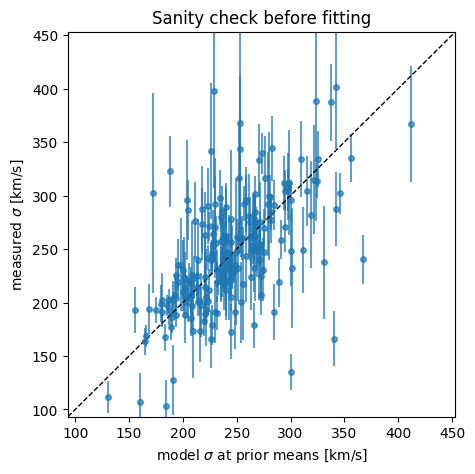

In [10]:
z_S, z_L = data["z_S"], data["z_L"]
velDisp, velDispErr = data["velDisp"], data["velDispErr"]
theta_E, seeing_atm, theta_ap = data["theta_E"], data["seeing_atm"], data["theta_ap"]

sigma_prior_mean = rings2cosmo.vel(z_S, z_L, theta_E, seeing_atm, theta_ap,
                                   alpha=2.0, beta=0.18, delta=2.4, gamma=1.0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(sigma_prior_mean, velDisp, yerr=velDispErr, fmt="o", ms=4, alpha=0.7)
lim = [min(sigma_prior_mean.min(), velDisp.min()) * 0.9, max(sigma_prior_mean.max(), velDisp.max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel=r"model $\sigma$ at prior means [km/s]",
       ylabel=r"measured $\sigma$ [km/s]", title="Sanity check before fitting")
plt.show()

## 4. Best-fit parameters by optimisation

This is the completed optimization function. Here we define `optimize_lens_parameters` which takes the data arguments and the prior settings, and runs the optimizer to return the four best-fit parameters.

The prior settings are the ones from `mcmcplot.py`. They were named `var_*` there, but they are used as
standard deviations, so they are renamed `sd_*` here.

In [11]:
# Prior means and widths (standard deviations) - from mcmcplot.py
mean_alpha, sd_alpha = 2.0, 0.08
mean_beta,  sd_beta  = 0.18, 0.13
mean_delta, sd_delta = 2.4, 0.11
gamma_ini = 1.0          # starting value for gamma (no prior on gamma)

priors = dict(alpha_0_value=mean_alpha, eps_alpha_0_value=sd_alpha,
              beta_0_value=mean_beta,   eps_beta_0_value=sd_beta,
              delta_0_value=mean_delta, eps_delta_0_value=sd_delta)
starts = dict(alpha_ini=mean_alpha, beta_ini=mean_beta, delta_ini=mean_delta, gamma_ini=gamma_ini)
data_args = (z_S, z_L, velDisp, velDispErr, theta_E, seeing_atm, theta_ap)   # order rings2cosmo expects

labels = [r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
names = ["alpha", "beta", "delta", "gamma"]


def optimize_lens_parameters(data_args, priors, starts, seed=11):
    """Maximum a posteriori (MAP) parameters: maximises log-prior + log-likelihood."""
    X_param = rings2cosmo.minimization_logprobability(*data_args, seed=seed, **starts, **priors)
    print("The parameters that maximize the probability of observing the data given the model are:\n")
    for sym, val in zip("αβδγ", X_param):
        print(f"  {sym} = {val:.3f}")
    return X_param


X_map = optimize_lens_parameters(data_args, priors, starts)
X_ml = rings2cosmo.minimization_loglikelihood(*data_args, seed=11, **starts)
print("\nMaximum likelihood (no priors):", np.round(X_ml, 3))

The parameters that maximize the probability of observing the data given the model are:

  α = 1.993
  β = 0.180
  δ = 2.400
  γ = 1.060

Maximum likelihood (no priors): [1.835 0.328 2.479 0.842]


## 5. Sampling the posterior with `emcee`

A point estimate says nothing about uncertainties or correlations between parameters. MCMC draws samples
from the full posterior. `emcee` runs an *ensemble* of walkers that propose moves using each other's
positions, which makes it insensitive to how the parameters are scaled.

Settings to know:

* `n_walkers`: at least 2 × `n_dim`; more walkers give smoother posteriors. `mcmcplot.py` used 100.
* `n_burn`: steps discarded while walkers move from the starting ball into the typical set.
* `n_steps`: production steps kept. You need many autocorrelation times' worth (section 6).
* `processes`: number of CPU cores. Leave as `None` for a first run; parallel runs are only faster
  when each likelihood call is expensive.

The values below are deliberately smaller than in `mcmcplot.py` (100 / 500 / 5000) so the tutorial
runs in a few minutes. For a real analysis, switch `QUICK = False`.

In [12]:
seed = 11
np.random.seed(seed)
n_dim = 4

n_walkers, n_burn, n_steps = 100, 500, 5000      # settings from mcmcplot.py

sampler = rings2cosmo.logprobability_sampling(*data_args, seed=seed, **starts, **priors,
                                              n_dim=n_dim, n_walkers=n_walkers,
                                              n_burn=n_burn, n_steps=n_steps,
                                              progress=True)

Running burn-in ...


100%|██████████| 500/500 [00:42<00:00, 11.79it/s]


Sampling ...


100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s]


## 6. Diagnosing the chains

**Never read results off a chain you have not inspected.** Three quick checks:

1. **Trace plots** (the plot `mcmcplot.py` was building): every walker's position versus step number.
   Healthy chains look like stationary "fuzzy caterpillars" with no trends or stuck walkers.
2. **Acceptance fraction**: roughly 0.2–0.6 is typical for `emcee`. Near 0 means walkers are stuck;
   near 1 means steps are tiny.
3. **Integrated autocorrelation time** τ: how many steps it takes to get an independent sample. The
   chain should be at least ~50 τ long for τ itself to be trustworthy, and τ sets how much to thin.

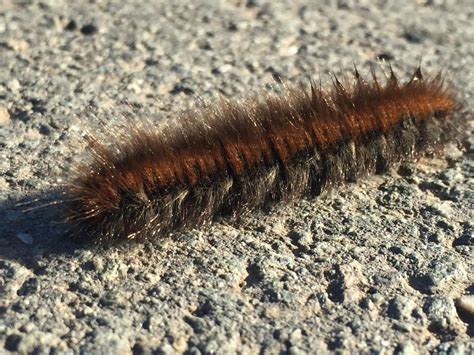<img src="files/content/hairy_molly.jpg" width="400">


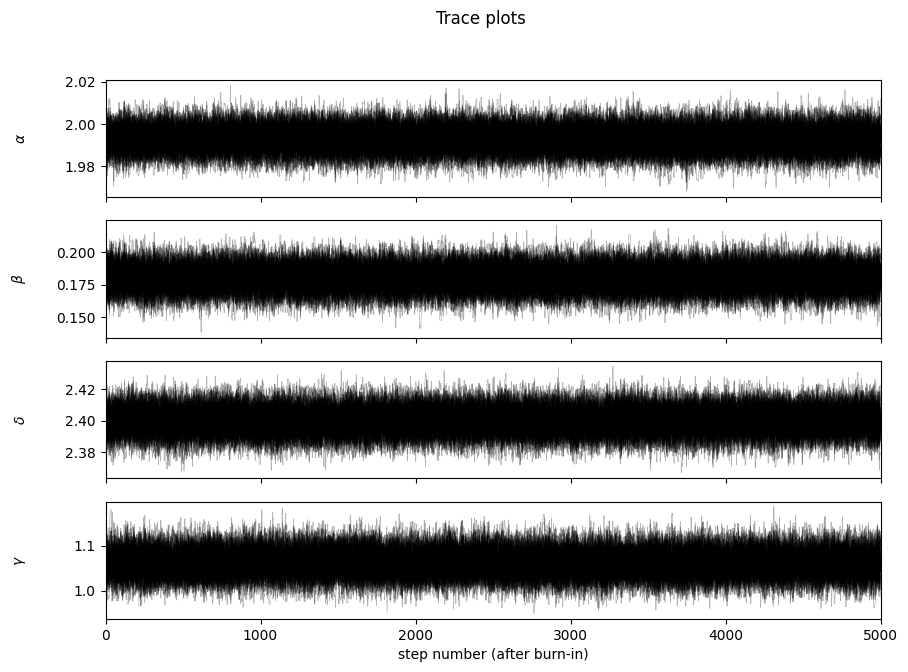

In [13]:
samples = sampler.get_chain()          # shape (n_steps, n_walkers, n_dim)

fig, axes = plt.subplots(n_dim, figsize=(10, 7), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3, lw=0.5)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number (after burn-in)")
fig.suptitle("Trace plots")
plt.show()

In [14]:
acc = sampler.acceptance_fraction
print(f"Mean acceptance fraction: {acc.mean():.3f}  (min {acc.min():.3f}, max {acc.max():.3f})")

try:
    tau = sampler.get_autocorr_time()
    print("Autocorrelation time per parameter:", np.round(tau, 1))
except emcee.autocorr.AutocorrError as err:
    # Raised when the chain is shorter than 50 tau: the estimate exists but is unreliable.
    tau = sampler.get_autocorr_time(quiet=True)
    print("Chain is too short for a reliable tau estimate - run longer!")
    print("Rough autocorrelation time:", np.round(tau, 1))

print(f"Chain length / max(tau) = {n_steps / np.max(tau):.0f}  (want >= 50)")

Mean acceptance fraction: 0.593  (min 0.573, max 0.612)
Autocorrelation time per parameter: [42.9 42.7 42.3 43.7]
Chain length / max(tau) = 115  (want >= 50)


Use τ to build the final flat sample: discard a couple of τ from the start (on top of the burn-in already
removed) and keep roughly one sample every τ/2 steps.

In [15]:
discard = int(2 * np.max(tau))
thin = max(1, int(0.5 * np.min(tau)))
flat = sampler.get_chain(discard=discard, thin=thin, flat=True)
print(f"discard={discard}, thin={thin} -> {flat.shape[0]} independent-ish samples")

discard=87, thin=21 -> 23300 independent-ish samples


## 7. Results

### Corner plot

The diagonal panels are the marginal posterior of each parameter; the off-diagonal panels show
correlations between pairs. Physically, α, β, δ and γ are partly degenerate: a steeper mass profile can
be traded against anisotropy or against γ while predicting the same dispersions, which is why the priors
on α, β and δ matter so much for the γ constraint.

**Look closely at the widths.** On the mock sample, the α, β and δ posteriors come out at almost exactly
their prior widths divided by $\sqrt{N}$ (e.g. 0.08/√50 ≈ 0.011 for α), and only γ is really set by
the data. That is a consequence of how the priors are coded; see item 1 in section 8.

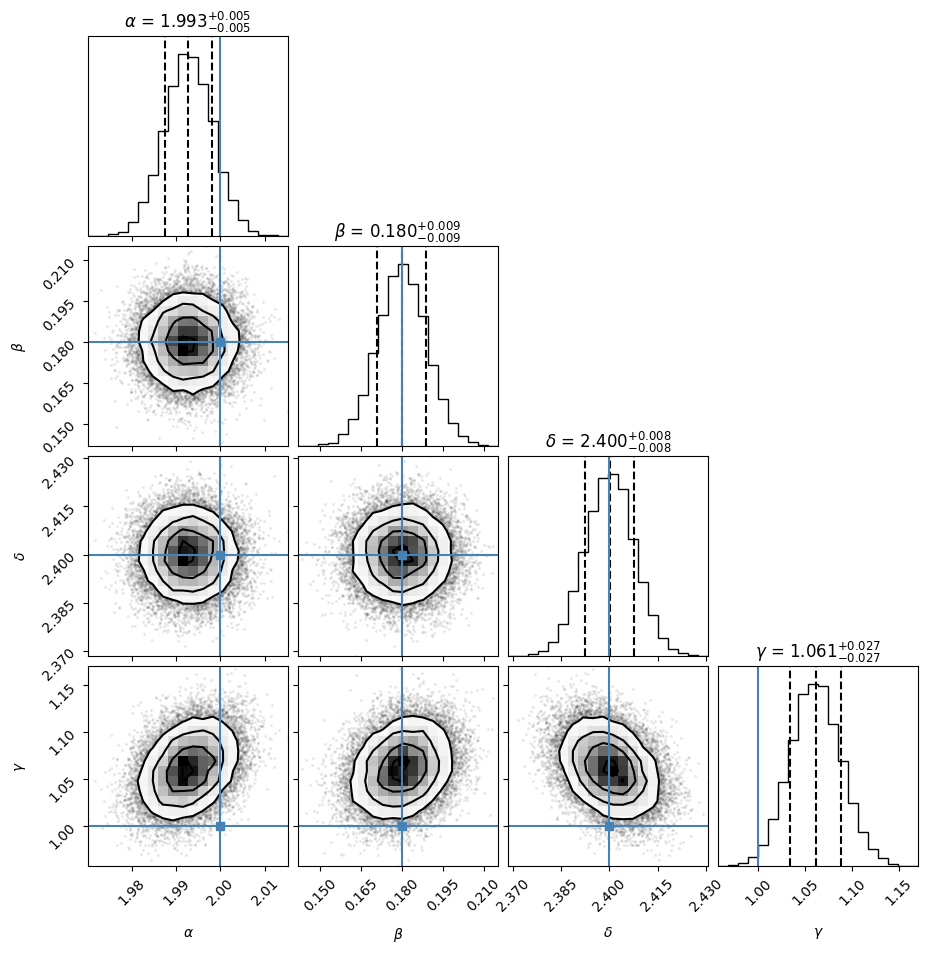

In [17]:
import corner

truths = [TRUE_PARAMS[n] for n in names]
fig = corner.corner(flat, labels=labels, truths=truths, show_titles=True,
                    title_fmt=".3f", quantiles=[0.16, 0.5, 0.84])
plt.show()

### Credible intervals

Report the median and the 16th/84th percentiles (a 68% credible interval) rather than mean ± std, since
the posteriors need not be symmetric.

In [19]:
rows = []
for i, n in enumerate(names):
    lo, med, hi = np.percentile(flat[:, i], [16, 50, 84])
    rows.append(dict(parameter=n, median=med, minus=med - lo, plus=hi - med, MAP=X_map[i],
                     **({"true": TRUE_PARAMS[n]})))
summary = pd.DataFrame(rows).set_index("parameter")
summary.round(3)

,median,minus,plus,MAP,true
parameter,,,,,
alpha,1.993,0.005,0.005,1.993,2.00
beta,0.180,0.009,0.009,0.180,0.18
delta,2.400,0.008,0.008,2.400,2.40
gamma,1.061,0.027,0.027,1.060,1.00


### Does the model describe the data?

Push posterior samples back through the model and compare with the measurements. Residuals normalised by
the errors should scatter around zero with unit width. A χ² per lens well above 1 means the errors are
underestimated or the model is missing something (for example, lens-to-lens scatter in α).

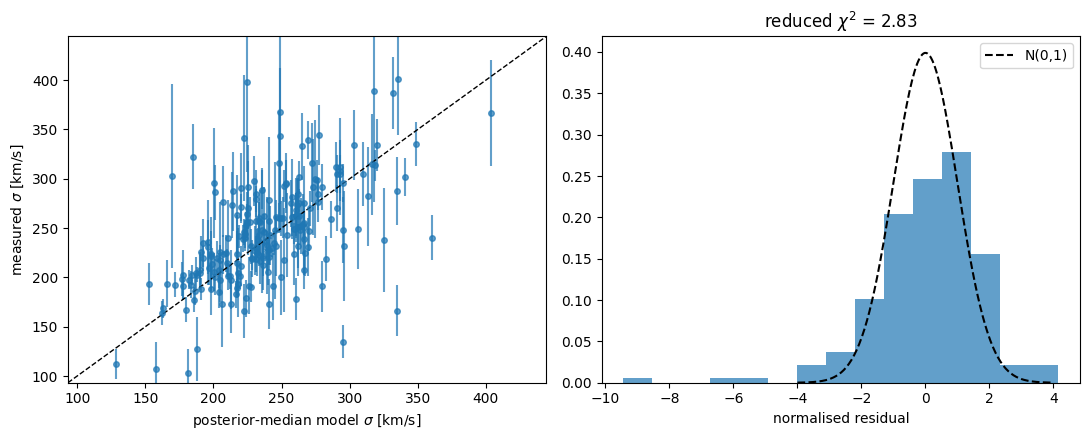

In [20]:
rng = np.random.default_rng(0)
draws = flat[rng.choice(len(flat), size=200, replace=False)]
pred = np.array([rings2cosmo.vel(z_S, z_L, theta_E, seeing_atm, theta_ap, *p) for p in draws])
pred_med = np.median(pred, axis=0)

resid = (velDisp - pred_med) / velDispErr
chi2_red = np.sum(resid**2) / (len(velDisp) - n_dim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.errorbar(pred_med, velDisp, yerr=velDispErr, fmt="o", ms=4, alpha=0.7)
lim = [min(pred_med.min(), velDisp.min()) * 0.9, max(pred_med.max(), velDisp.max()) * 1.1]
ax1.plot(lim, lim, "k--", lw=1)
ax1.set(xlim=lim, ylim=lim, xlabel=r"posterior-median model $\sigma$ [km/s]",
        ylabel=r"measured $\sigma$ [km/s]")
ax2.hist(resid, bins=15, density=True, alpha=0.7)
x = np.linspace(-4, 4, 200)
ax2.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), "k--", label="N(0,1)")
ax2.set(xlabel="normalised residual", title=fr"reduced $\chi^2$ = {chi2_red:.2f}")
ax2.legend()
plt.tight_layout()
plt.show()

# 8. Einstein Radius Conventions & Multi-Group Analysis

Different lens modeling software and studies use different conventions for the Einstein radius when moving from spherical to elliptical profiles (where the axis ratio is $q = b/a$):

1. **Major Axis Convention**: $\theta_E$ is defined along the semi-major axis of the elliptical profile, corresponding directly to the major axis radius $a$.
2. **Intermediate Axis Convention**: Rescales $\theta_E$ such that the area inside the critical curve is conserved, making it independent of the axis ratio ($\theta_{E,\text{int}} = \sqrt{q}\theta_{E,\text{maj}}$).
3. **Circular Convention**: Uses an ellipticity-based parameterization ($\theta_{E,\text{s}} = \sqrt{2q^2/(1+q^2)}\theta_{E,\text{maj}}$) to optimize higher-order analytical calculations of magnification.

In [24]:
def change_convention(theta_E, axis_ratio, conversion, convention):
          fq = []
          if conversion == 'major':
            print('Converting to major...')
            for i, q in enumerate(axis_ratio):
                if convention[i] == 'major':
                  fq.append(1)

                elif convention[i] == 'Intermediate':
                  fq.append(np.sqrt(q))

                elif convention[i] == 'circular':
                  fq.append(np.sqrt((1+q**2)/(2*q**2)))

                else:
                  fq.append(1)
          elif conversion == 'intermediate':
            print('Converting to intermediate...')
            for i, q in enumerate(axis_ratio):
                if convention[i] == 'major':
                  fq.append(1/np.sqrt(q))
                elif convention[i] == 'Intermediate':
                  fq.append(1)
                elif convention[i] == 'circular':
                  fq.append(np.sqrt((1+q**2)/(2*q)))
                else:
                    fq.append(1)
          elif conversion == 'circular':
            print('Converting to circular...')
            for i, q in enumerate(axis_ratio):
                if convention[i] == 'major':
                  fq.append(np.sqrt((2*q**2)/(1+q**2)))
                elif convention[i] == 'Intermediate':
                  fq.append(np.sqrt((2*q)/(1+q**2)))
                elif convention[i] == 'circular':
                  fq.append(1)
                else:
                    fq.append(1)
          return np.array(fq) * theta_E

### Function to divide data by an observable

This function takes the main DataFrame and an observable (column name) as input and returns a dictionary of sub-DataFrames, where each key corresponds to a unique value or defined bin in the observable column.

* **Physical Motivation**: Splitting or binning the dataset by physical observables can expose systematic trends in your model. For instance, binning by the ratio of the Einstein radius to the effective radius (e.g., `theta_E` / `theta_Eff`) is particularly interesting; this ratio indicates how far out from the central, baryon-dominated region of the lens galaxy the gravitational deflection is actually occurring, allowing you to probe the transition between baryonic and dark matter dominance.

In [23]:
def divide_data_by_observable(dataframe, observable_col, binning_method='none', num_bins=None):
    """
    Divides a DataFrame into sub-DataFrames based on unique values in a specified observable column,
    with optional binning for numerical columns.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        observable_col (str): The name of the column to use for dividing the data.
        binning_method (str, optional): Method for binning numerical columns.
            'none': No binning (default).
            'equal_width': Bins are of equal width.
            'equal_count': Each bin has approximately the same number of observations.
        num_bins (int, optional): The number of bins to create when binning_method is specified.

    Returns:
        dict: A dictionary where keys are unique values (or bin labels) from the observable column
              and values are the corresponding sub-DataFrames.
    """
    if observable_col not in dataframe.columns:
        raise ValueError(f"Column '{observable_col}' not found in the DataFrame.")

    # Drop rows where the observable column is NaN
    df_cleaned = dataframe.dropna(subset=[observable_col])

    if binning_method == 'none' or not pd.api.types.is_numeric_dtype(df_cleaned[observable_col]):
        # Original behavior for non-numeric or no binning
        grouped_data = df_cleaned.groupby(observable_col)
        divided_data = {name: group for name, group in grouped_data}
    else:
        if num_bins is None or not isinstance(num_bins, int) or num_bins <= 0:
            raise ValueError("num_bins must be a positive integer for binning methods 'equal_width' or 'equal_count'.")

        if binning_method == 'equal_width':
            # Equal-width binning
            # Labels=False returns integer indicators of the bins
            bins = pd.cut(df_cleaned[observable_col], bins=num_bins, include_lowest=True, right=True)
        elif binning_method == 'equal_count':
            # Equal-count binning
            # duplicates='drop' handles cases with identical values that would create empty bins
            bins = pd.qcut(df_cleaned[observable_col], q=num_bins, duplicates='drop')
        else:
            raise ValueError(f"Unknown binning method: '{binning_method}'. Choose 'none', 'equal_width', or 'equal_count'.")

        grouped_data = df_cleaned.groupby(bins)
        # Convert interval objects to string keys for dictionary
        divided_data = {str(name): group for name, group in grouped_data}
    return divided_data

    for group_name, sub_df in divided_data.items():
        # Prepare data_args for the current group
        group_data = {
            "z_S": sub_df["z_S"].to_numpy(dtype=float),
            "z_L": sub_df["z_L"].to_numpy(dtype=float),
            "velDisp": sub_df["velDisp"].to_numpy(dtype=float),
            "velDispErr": sub_df["velDispErr"].to_numpy(dtype=float),
            "theta_E": sub_df["theta_E_rad"].to_numpy(dtype=float),
            "seeing_atm": sub_df["Seeing_rad"].to_numpy(dtype=float),
            "theta_ap": sub_df["theta_ap_rad"].to_numpy(dtype=float),
        }

        # Optimization
        X_map, X_ml = run_optimization_for_group(group_data, priors, starts, group_name=group_name)

        # MCMC Sampling
        sampler = run_mcmc_sampling_for_group(group_data, priors, starts, **mcmc_params, group_name=group_name)

        # Diagnostics
        run_diagnostics_for_group(sampler, group_data, X_map, names, labels, TRUE_PARAMS, USING_MOCK, mcmc_params['n_dim'], mcmc_params['n_steps'], group_name=group_name)

        print(f"\n{'='*80}\n") # Separator for clarity between groups



### 8b. Step-by-Step Multi-Group Analysis Functions

To analyze how different lens subsets or conventions influence our parameters, we define four separate functions. This allows participants to run each phase of the analysis individually and inspect the results step-by-step:

1. **`run_group_optimization(divided_data, priors, starts, seed=11)`**
   * `divided_data` (dict): A dictionary of sub-DataFrames output by `divide_data_by_observable`.
   * `priors` (dict): Gaussian prior parameters for the mass slope ($\alpha$), orbital anisotropy ($\beta$), and luminosity slope ($\delta$).
   * `starts` (dict): Initial values for optimization variables ($\alpha_{\text{ini}}, \beta_{\text{ini}}, \delta_{\text{ini}}, \gamma_{\text{ini}}$).
   * `seed` (int): Random seed for reproducibility.
   * **Returns**: A dictionary of MAP and ML optimization result lists for each subgroup.

2. **`run_group_sampling(divided_data, priors, starts, n_dim=4, n_walkers=100, n_burn=500, n_steps=5000, seed=11)`**
   * `divided_data` (dict): The dictionary of grouped sub-DataFrames.
   * `priors` & `starts` (dict): Prior specifications and initial guesses for the model parameters.
   * `n_dim` (int): Dimensionality of the model parameter space (default: 4).
   * `n_walkers` (int): Number of independent walkers in the MCMC ensemble.
   * `n_burn` (int): Number of initial burn-in steps to discard.
   * `n_steps` (int): Number of production steps to run after resetting burn-in.
   * `seed` (int): Seed for initial walker coordinates.
   * **Returns**: A dictionary mapping group names to their respective completed `emcee.EnsembleSampler` object.

3. **`run_group_diagnostics(samplers, labels=None)`**
   * `samplers` (dict): Dictionary of completed group samplers.
   * `labels` (list, optional): Latex labels for the parameters (defaults to `["\\alpha", "\\beta", "\\delta", "\\gamma"]`).
   * **Action**: Plots step traces for all parameters per subgroup and prints diagnostics like acceptance fraction and autocorrelation times.

4. **`plot_group_gamma_results(samplers, labels=None)`**
   * `samplers` (dict): Dictionary of completed group samplers containing posterior chains.
   * `labels` (list, optional): Parameter labels.
   * **Action**: Extracts the $\gamma$ chain, discards burn-in, thins samples based on autocorrelation time, computes the 16th, 50th, and 84th percentiles, and generates a clean comparative horizontal errorbar plot comparing group posteriors against General Relativity ($\gamma=1$).

### Function to modify an observable

### How the `modify_observable` Function Works

This utility function allows you to dynamically adjust physical measurements within your lensing dataset (such as velocity dispersions or Einstein radii) to test systematic shifts.

You can modify a target column in two ways:
1. **Multiplicative Factor**: Multiply the values by a specified `factor` (e.g., passing `1.10` increases the entire dataset column by 10%).
2. **Additive Shift**: Add a constant offset directly using `fixed_amount` (e.g., adding a systematic offset of +5 km/s).

In [25]:
def modify_observable(dataframe, observable_col, factor=None, fixed_amount=None):
    """
    Modifies the values of a given observable column in a DataFrame by either adding a specified percentage or a flat fixed amount.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        observable_col (str): The name of the column to modify.
        factor (float, optional): Multiplicative factor to change observable by
        fixed_amount (float, optional): A constant value to add directly (e.g., 10 for +10 units).

    Returns:
        pd.DataFrame: A new DataFrame with the specified observable column modified.
    """
    if observable_col not in dataframe.columns:
        raise ValueError(f"Column '{observable_col}' not found in the DataFrame.")

    if not pd.api.types.is_numeric_dtype(dataframe[observable_col]):
        raise TypeError(f"Column '{observable_col}' is not numeric and cannot be modified.")

    if percentage is not None and fixed_amount is not None:
        raise ValueError("Please specify only one modifier: 'percentage' or 'fixed_amount'.")

    df_modified = dataframe.copy()
    if percentage is not None:
        df_modified[observable_col] = df_modified[observable_col] * (factor)
    elif fixed_amount is not None:
        df_modified[observable_col] = df_modified[observable_col] + fixed_amount
    else:
        raise ValueError("Either 'factor' or 'fixed_amount' must be provided.")

    return df_modified

## 9. Varying $\gamma$ Parameterization

In standard Parameterized Post-Newtonian (PPN) formalisms, $\gamma$ is assumed to be a constant slip parameter across all lens systems. However, to test whether deviations from General Relativity scale with the properties of the lenses themselves, `rings2cosmo` supports modeling $\gamma$ as a linear function of a normalized lens covariate property $x_i$:

$$\gamma_i = \gamma_0 + \gamma_1 x_i$$

where:
* $\gamma_0$ is the baseline slip parameter at the sample mean of the covariate.
* $\gamma_1$ is the slope parameterizing the variation strength across the sample.
* $x_i$ is a normalized covariate computed from one of the lens variables (`z_S`, `z_L`, `theta_E`, `velDisp`, `DLS`, `DL`, `DS`).

### Covariate Normalization in `rings2cosmo`
For properties such as redshift and velocity dispersion (`z_S`, `z_L`, `theta_E`, `velDisp`), the normalization is:
$$x_i = \frac{q_i - \text{mean}(q)}{\text{max}(q) - \text{min}(q)}$$
Where $q = 1 + z$ for redshifts. Thus, $x_i$ is zero for the average lens, making $\gamma_0$ the slip parameter value at the sample mean, and $\gamma_1$ represents the change in $\gamma$ across the full range of the sample.

Below, we show how to set up this built-in varied-gamma scaling parameterization and run a maximum a posteriori (MAP) optimization utilizing these parameters.

In [26]:
# Example demonstrating how to initialize, optimize, and run MCMC sampling for the real varied-gamma parameterization built into rings2cosmo
print("Setting up built-in varying gamma parameterization...")

# We will use 'velDisp' as our covariate of interest
# To activate varied-gamma mode in rings2cosmo, we provide both a 'variable' name
# and an initial guess 'gamma_1_ini'. This expands our parameter dimensions to 5.
starts_varied = dict(
    alpha_ini=mean_alpha,
    beta_ini=mean_beta,
    delta_ini=mean_delta,
    gamma_ini=1.0,         # This behaves as gamma_0 in a varied-gamma run
    gamma_1_ini=0.0,       # Giving gamma_1_ini switches on the varied run
    variable='theta_E'
)

# 1. Perform Maximum A Posteriori (MAP) fit
X_map_varied = rings2cosmo.minimization_logprobability(*data_args, seed=11, **starts_varied, **priors)

print("\nMAP parameters for the varying gamma model (gamma = gamma_0 + gamma_1 * x_i):")
for sym, val in zip(["alpha", "beta", "delta", "gamma_0", "gamma_1"], X_map_varied):
    print(f"  {sym} = {val:.4f}")

# 2. Run MCMC Sampling with emcee (using 5 dimensions for the varied-gamma mode)
print("\nRunning posterior MCMC sampling for the varying gamma model...")
n_dim_varied = 5
sampler_varied = rings2cosmo.logprobability_sampling(*data_args, seed=11, **starts_varied, **priors,
                                                     n_dim=n_dim_varied, n_walkers=100,
                                                     n_burn=100, n_steps=1000,
                                                     progress=True)

# Extract chains
samples_varied = sampler_varied.get_chain(discard=200, thin=10, flat=True)
print(f"\nRetrieved {samples_varied.shape[0]} samples from the posterior.")

# Summarize key parameters
for i, sym in enumerate(["alpha", "beta", "delta", "gamma_0", "gamma_1"]):
    lo, med, hi = np.percentile(samples_varied[:, i], [16, 50, 84])
    print(f"  {sym}: median = {med:.4f}, 68% credible interval = [{lo:.4f}, {hi:.4f}]")

Setting up built-in varying gamma parameterization...

MAP parameters for the varying gamma model (gamma = gamma_0 + gamma_1 * x_i):
  alpha = 1.9906
  beta = 0.1800
  delta = 2.4000
  gamma_0 = 1.0408
  gamma_1 = -1.6135

Running posterior MCMC sampling for the varying gamma model...
Running burn-in ...


100%|██████████| 100/100 [00:09<00:00, 10.36it/s]


Sampling ...


  1%|          | 12/1000 [00:01<01:23, 11.83it/s]Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/rings2cosmo.py", line 281, in log_probability
  File "/content/rings2cosmo.py", line 206, in log_likelihood
  File "/content/rings2cosmo.py", line 146, in vel
  File "/usr/local/lib/python3.13/dist-packages/astropy/cosmology/_src/flrw/base.py", line 1128, in angular_diameter_distance_z1z2
    return self._comoving_transverse_distance_z1z2(z1, z2) / (z2 + 1.0)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/astropy/cosmology/_src/flrw/base.py", line 1028, in _comoving_transverse_distance_z1z2
    dc = self._comoving_distance_z1z2(z1, z2)
  File "/usr/local/lib/python3.13/dist-packages/astropy/cosmology/_src/flrw/lambdacdm.py", line 380, in _hyperg

emcee: Exception while calling your likelihood function:
  params: [ 1.99165617  0.15614123  2.39874279  1.00066729 -1.17690822]
  args: (array([1.364     , 0.898     , 0.897     , 1.518     , 1.332     ,
       1.179     , 1.346     , 1.297     , 1.2843771 , 1.016     ,
       1.3958951 , 1.182     , 0.893     , 1.033611  , 1.311     ,
       1.1133329 , 1.0233349 , 1.2885885 , 1.446     , 1.2108935 ,
       1.0862565 , 0.87442356, 1.4517026 , 0.978     , 2.45      ,
       2.82      , 2.2491    , 2.36      , 2.6335    , 2.2335    ,
       2.4       , 2.4       , 2.5       , 2.45      , 2.76      ,
       2.13      , 2.73      , 2.83      , 2.265     , 3.595     ,
       2.941     , 3.399     , 2.092     , 3.263     , 2.73      ,
       0.48      , 2.536     , 2.239     , 1.405     , 3.042     ,
       0.91      , 2.        , 0.9818    , 1.231     , 1.1046    ,
       0.7477    , 0.9199    , 0.6239    , 0.9628    , 0.7401    ,
       0.8326    , 1.2907    , 0.5327    , 0.6371    , 0.3

KeyboardInterrupt: 

## 10. Model Comparison using the Bayesian Information Criterion (BIC)

To determine whether the additional parameter $\gamma_1$ introduced in the varying $\gamma$ model is statistically justified by the data, we can use the **Bayesian Information Criterion (BIC)**:

$$\text{BIC} = k \ln(N) - 2 \ln(\widehat{\mathcal{L}})$$

where:
* $k$ is the number of free parameters in the model ($k=4$ for constant $\gamma$; $k=5$ for varying $\gamma$).
* $N$ is the number of data points (lenses in our sample).
* $\widehat{\mathcal{L}}$ is the maximum likelihood estimate (MLE) of the model.

### Jeffreys' Scale for Model Comparison ($\Delta \text{BIC}$)
We define $\Delta \text{BIC} = \text{BIC}_{\text{constant}} - \text{BIC}_{\text{varying}}$. The classical Jeffreys' scale provides a guide to assess the strength of evidence in favor of the varying model:

| $\Delta \text{BIC}$ | Evidence Strength in Favor of Varying $\gamma$ |
|---|---|
| $< 0$ | Supports the simpler constant $\gamma$ model |
| $0$ to $2$ | Weak / barely worth mentioning |
| $2$ to $6$ | Positive evidence |
| $6$ to $10$ | Strong evidence |
| $> 10$ | Very strong / Decisive evidence |

In [22]:
def calculate_bic(log_like_max, k, n_samples):
    """Computes the Bayesian Information Criterion (BIC).

    Parameters:
      log_like_max (float): The maximum value of the log-likelihood.
      k (int): Number of free parameters in the model.
      n_samples (int): Number of independent observations (lenses).
    """
    import numpy as np
    return k * np.log(n_samples) - 2 * log_like_max

# --- HOW TO RUN THE BIC MODEL COMPARISON ---
# To run the comparison in your workspace, copy and execute these lines:
#
# # 1. Compute BIC for the Constant Gamma Model (k=4)
# bic_const = calculate_bic(log_like_const, k=4, n_samples=N)
#
# # 2. Compute BIC for the Varying Gamma Model (k=5)
# bic_varied = calculate_bic(log_like_varied, k=5, n_samples=N)
#
# # 3. Compute Delta BIC to find the best model
# delta_bic = bic_const - bic_varied
#
# --- HOW TO INTERPRET YOUR DELTA BIC RESULTS ---
# * If Delta BIC < 0: The simpler Constant Gamma model is statistically favored.
# * If 0 <= Delta BIC < 2: Weak evidence in favor of the Varying Gamma model.
# * If 2 <= Delta BIC < 6: Positive evidence in favor of the Varying Gamma model.
# * If 6 <= Delta BIC < 10: Strong evidence in favor of the Varying Gamma model.
# * If Delta BIC >= 10: Decisive evidence in favor of the Varying Gamma model.

--- BIC Model Comparison (N = 206 lenses) ---
Constant Gamma Model (k=4):  Max ln(L) = -1107.30, BIC = 2235.90
Varying Gamma Model (k=5):   Max ln(L) = -1028.75, BIC = 2084.14
Delta BIC (Const - Varying):       151.76

Interpretation:
  Very strong / Decisive evidence in favor of the Varying Gamma model.
